# Análise de Sentimentos em Reclamações de Clientes
## Pipeline de Deep Learning com PyTorch + LSTM Bidirecional

| | |
|---|---|
| **Caso corporativo** | Central de Atendimento ao Cliente (SAC) |
| **Objetivo** | Classificar reclamações como Negativa, Neutra ou Positiva |
| **Benefício** | Triagem automática para priorização de atendimento |
| **Dataset** | Textos em Português Brasileiro |
| **Modelo** | Embedding + Bi-LSTM + Classificador Linear |

## 1. Contextualização Teórica

**Análise de Sentimentos** (Sentiment Analysis) é uma tarefa de NLP que classifica o tom emocional de um texto.

**Por que LSTM?**
- Textos têm dependências de longo alcance: *"o produto **não** é bom"* vs *"o produto é **muito** bom"*
- LSTMs memorizam contexto anterior através das células de memória (cell state)
- A versão **Bidirecional** lê o texto da esquerda→direita E direita→esquerda

**Pipeline:**
```
Texto bruto → Limpeza → Tokenização → Embedding → Bi-LSTM → Classificador → Sentimento
```

## 2. Imports e Configuração

In [25]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Verificar GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM disponível: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Dispositivo: cpu


## 3. Dataset — Reclamações de Clientes em Português

In [26]:
# Carregar dataset de reclamações de SAC a partir do arquivo CSV
CSV_PATH = 'reclamacoes_clientes.csv'

label_names = {0: 'Negativo', 1: 'Neutro', 2: 'Positivo'}
cores = {'Negativo': '#e74c3c', 'Neutro': '#f39c12', 'Positivo': '#27ae60'}

# encoding utf-8-sig remove o BOM (﻿) que pode vir no início do arquivo
df = pd.read_csv(CSV_PATH, encoding='utf-8-sig')

# Derivar o nome do sentimento a partir do label (garante consistência)
df['sentimento'] = df['label'].map(label_names)
df['num_palavras'] = df['texto'].apply(lambda x: len(str(x).split()))

print(f'Arquivo carregado: {CSV_PATH}')
print(f'Total de exemplos: {len(df)}')
print()
print(df['sentimento'].value_counts().to_string())
print()
print(df.groupby('sentimento')['num_palavras'].describe().round(1))

Arquivo carregado: reclamacoes_clientes.csv
Total de exemplos: 1000

sentimento
Negativo    400
Neutro      300
Positivo    300

            count  mean  std  min   25%   50%   75%   max
sentimento                                               
Negativo    400.0  11.1  1.8  6.0  10.0  11.0  12.0  16.0
Neutro      300.0   9.9  1.2  8.0   9.0  10.0  11.0  13.0
Positivo    300.0   9.6  1.0  8.0   9.0   9.0  10.0  12.0


## 4. Exploração dos Dados (EDA)

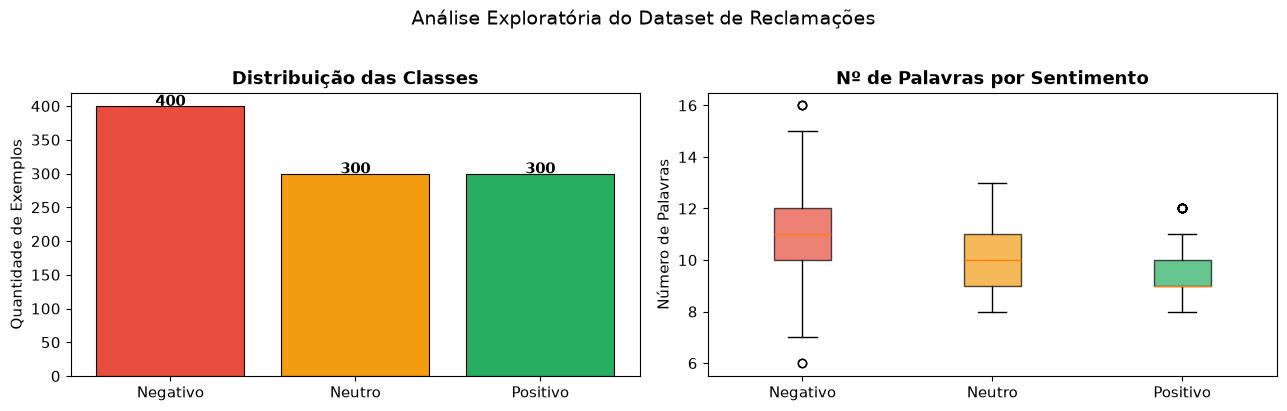

Exemplos de cada classe:
  [Negativo]: "Produto com manual somente em inglês e chamado aberto sem nenhuma atualização..."
  [Neutro]: "Entrega dentro do esperado, produto chegou em bom estado de conservação..."
  [Positivo]: "Entrega antecipada e produto impecável, embalagem perfeita e reforçada..."


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribuição das classes
contagem = df['sentimento'].value_counts().reindex(['Negativo', 'Neutro', 'Positivo'])
bars = axes[0].bar(contagem.index, contagem.values,
                   color=[cores[s] for s in contagem.index], edgecolor='black', linewidth=0.8)
axes[0].set_title('Distribuição das Classes', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Quantidade de Exemplos')
for bar, val in zip(bars, contagem.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', fontweight='bold')

# Boxplot de comprimento por classe
dados_box = [df[df['sentimento'] == s]['num_palavras'].values
             for s in ['Negativo', 'Neutro', 'Positivo']]
bp = axes[1].boxplot(dados_box, tick_labels=['Negativo', 'Neutro', 'Positivo'], patch_artist=True)
for patch, cor in zip(bp['boxes'], cores.values()):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)
axes[1].set_title('Nº de Palavras por Sentimento', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Número de Palavras')

plt.suptitle('Análise Exploratória do Dataset de Reclamações', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Exemplos de cada classe:')
for sent in ['Negativo', 'Neutro', 'Positivo']:
    exemplo = df[df['sentimento'] == sent]['texto'].iloc[0]
    print(f'  [{sent}]: "{exemplo[:80]}..."')

## 5. Pré-processamento de Texto

Etapas:
1. **Normalização**: lowercase, remoção de pontuação
2. **Vocabulário**: mapeamento palavra → índice numérico
3. **Padding**: todas as sequências com mesmo comprimento

In [28]:
def preprocessar(texto):
    texto = texto.lower()
    texto = re.sub(r'[^a-záéíóúãõâêôàüç\s]', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

df['texto_limpo'] = df['texto'].apply(preprocessar)

# Exemplo de pré-processamento
idx = 0
print('Antes :', df['texto'].iloc[idx])
print('Depois:', df['texto_limpo'].iloc[idx])

Antes : Entrega dentro do esperado, produto chegou em bom estado de conservação
Depois: entrega dentro do esperado produto chegou em bom estado de conservação


In [29]:
def construir_vocabulario(textos, min_freq=1):
    contador = Counter()
    for texto in textos:
        contador.update(texto.split())
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for palavra, freq in sorted(contador.items()):
        if freq >= min_freq:
            vocab[palavra] = len(vocab)
    return vocab

MAX_LEN = 20  # máximo de palavras por texto

vocab = construir_vocabulario(df['texto_limpo'])
print(f'Tamanho do vocabulário: {len(vocab)} palavras únicas')
print(f'Comprimento máximo da sequência: {MAX_LEN} tokens')

def texto_para_sequencia(texto, vocab, max_len):
    tokens = texto.split()[:max_len]
    seq = [vocab.get(t, vocab['<UNK>']) for t in tokens]
    seq += [vocab['<PAD>']] * (max_len - len(seq))  # padding
    return seq

df['sequencia'] = df['texto_limpo'].apply(
    lambda x: texto_para_sequencia(x, vocab, MAX_LEN)
)

print(f'\nExemplo de codificação:')
print(f'  Texto  : {df["texto_limpo"].iloc[0]}')
print(f'  Índices: {df["sequencia"].iloc[0]}')

Tamanho do vocabulário: 458 palavras únicas
Comprimento máximo da sequência: 20 tokens

Exemplo de codificação:
  Texto  : entrega dentro do esperado produto chegou em bom estado de conservação
  Índices: [149, 101, 130, 162, 338, 58, 139, 44, 167, 97, 82, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## 6. Dataset e DataLoader PyTorch

In [30]:
class ReclamacoesDataset(Dataset):
    def __init__(self, sequencias, labels):
        self.sequencias = torch.tensor(sequencias, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequencias[idx], self.labels[idx]


X = list(df['sequencia'])
y = list(df['label'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_dataset = ReclamacoesDataset(X_train, y_train)
test_dataset  = ReclamacoesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16)

print(f'Treino : {len(train_dataset)} exemplos')
print(f'Teste  : {len(test_dataset)} exemplos')

# Verificar um batch
batch_seq, batch_lbl = next(iter(train_loader))
print(f'\nShape de um batch:')
print(f'  Sequências: {batch_seq.shape}  (batch_size x max_len)')
print(f'  Labels    : {batch_lbl.shape}  (batch_size)')

Treino : 800 exemplos
Teste  : 200 exemplos

Shape de um batch:
  Sequências: torch.Size([16, 20])  (batch_size x max_len)
  Labels    : torch.Size([16])  (batch_size)


## 7. Arquitetura do Modelo — Bi-LSTM

```
Entrada (índices)  → [batch, 20]
      ↓
Embedding Layer    → [batch, 20, 64]   # cada palavra vira vetor denso
      ↓
Bi-LSTM (2 layers) → [batch, 20, 256]  # lê texto nas 2 direções
      ↓
Hidden state final → [batch, 256]      # representação do texto completo
      ↓
Linear + Softmax   → [batch, 3]        # probabilidade de cada sentimento
```

In [31]:
class SentimentoLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers=2, dropout=0.4):
        super(SentimentoLSTM, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True     # lê esquerda→direita E direita→esquerda
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)  # *2 bidirecional

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        # Concatenar último estado oculto das duas direções
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(self.dropout(hidden))


# Hiperparâmetros
VOCAB_SIZE  = len(vocab)
EMBED_DIM   = 64
HIDDEN_DIM  = 128
NUM_CLASSES = 3
NUM_EPOCHS  = 40
LR          = 0.001

model = SentimentoLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nTotal de parâmetros treináveis: {total_params:,}')

SentimentoLSTM(
  (embedding): Embedding(458, 64, padding_idx=0)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)

Total de parâmetros treináveis: 624,003


## 8. Treinamento

In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=6, factor=0.5
)

historico = {'loss': [], 'acc': []}

print(f'Treinando por {NUM_EPOCHS} épocas no dispositivo: {device}')
print('-' * 55)

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0

    for seqs, lbls in train_loader:
        seqs, lbls = seqs.to(device), lbls.to(device)

        optimizer.zero_grad()
        outputs = model(seqs)
        loss = criterion(outputs, lbls)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss    += loss.item()
        total_correct += (outputs.argmax(1) == lbls).sum().item()
        total         += lbls.size(0)

    epoch_loss = total_loss / len(train_loader)
    epoch_acc  = total_correct / total
    historico['loss'].append(epoch_loss)
    historico['acc'].append(epoch_acc)
    scheduler.step(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Época {epoch+1:3d}/{NUM_EPOCHS} | '
              f'Loss: {epoch_loss:.4f} | Acc: {epoch_acc*100:.1f}%')

print('-' * 55)
print('Treinamento concluído!')

Treinando por 40 épocas no dispositivo: cpu
-------------------------------------------------------
Época  10/40 | Loss: 0.0480 | Acc: 98.9%
Época  20/40 | Loss: 0.0157 | Acc: 99.4%
Época  30/40 | Loss: 0.0113 | Acc: 99.6%
Época  40/40 | Loss: 0.0118 | Acc: 99.6%
-------------------------------------------------------
Treinamento concluído!


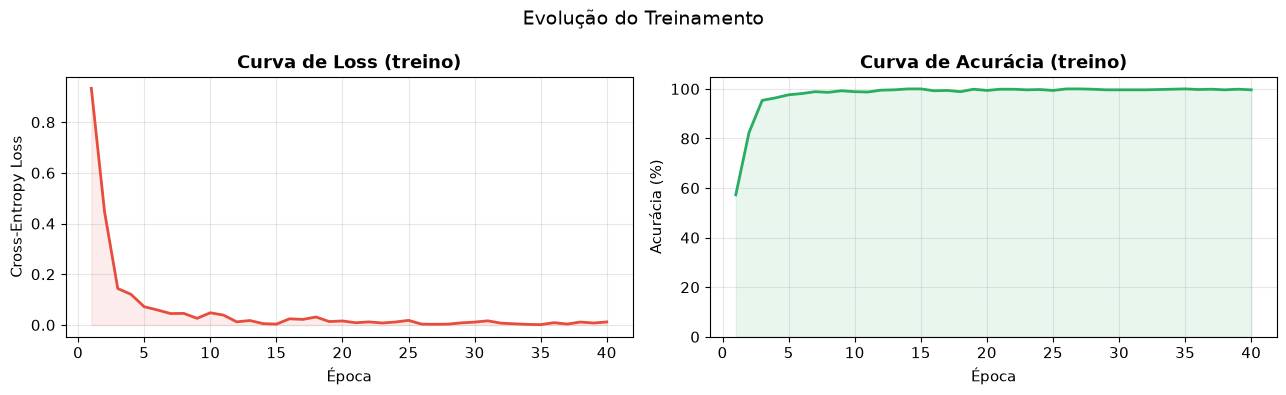

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

epocas = range(1, NUM_EPOCHS + 1)

axes[0].plot(epocas, historico['loss'], color='#e74c3c', linewidth=2)
axes[0].set_title('Curva de Loss (treino)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(True, alpha=0.3)
axes[0].fill_between(epocas, historico['loss'], alpha=0.1, color='#e74c3c')

axes[1].plot(epocas, [a*100 for a in historico['acc']], color='#27ae60', linewidth=2)
axes[1].set_title('Curva de Acurácia (treino)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Acurácia (%)')
axes[1].set_ylim(0, 105)
axes[1].grid(True, alpha=0.3)
axes[1].fill_between(epocas, [a*100 for a in historico['acc']], alpha=0.1, color='#27ae60')

plt.suptitle('Evolução do Treinamento', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Avaliação no Conjunto de Teste

In [22]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for seqs, lbls in test_loader:
        seqs = seqs.to(device)
        outputs = model(seqs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())

print('=== Relatório de Classificação ===')
print(classification_report(
    all_labels, all_preds,
    target_names=['Negativo', 'Neutro', 'Positivo']
))

=== Relatório de Classificação ===
              precision    recall  f1-score   support

    Negativo       1.00      1.00      1.00        80
      Neutro       1.00      1.00      1.00        60
    Positivo       1.00      1.00      1.00        60

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



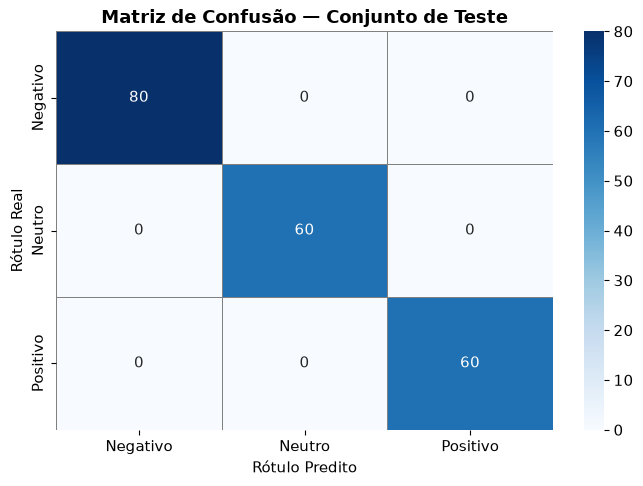

In [23]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Negativo', 'Neutro', 'Positivo'],
    yticklabels=['Negativo', 'Neutro', 'Positivo'],
    linewidths=0.5, linecolor='gray'
)
plt.title('Matriz de Confusão — Conjunto de Teste', fontsize=13, fontweight='bold')
plt.ylabel('Rótulo Real', fontsize=11)
plt.xlabel('Rótulo Predito', fontsize=11)
plt.tight_layout()
plt.show()

## 10. Inferência — Sistema de Triagem Automática de SAC

Simulação de como o modelo seria usado em produção para classificar reclamações em tempo real.

In [24]:
def classificar_reclamacao(texto):
    model.eval()
    texto_limpo = preprocessar(texto)
    seq = texto_para_sequencia(texto_limpo, vocab, MAX_LEN)
    tensor = torch.tensor([seq], dtype=torch.long).to(device)

    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1).cpu().numpy()[0]
        pred  = output.argmax(1).item()

    return {
        'sentimento'  : label_names[pred],
        'confianca'   : probs[pred],
        'neg'         : probs[0],
        'neu'         : probs[1],
        'pos'         : probs[2],
    }


# ── Novas reclamações do SAC ──────────────────────────────────────────────
novas_reclamacoes = [
    'Meu produto parou de funcionar depois de dois dias, péssima qualidade',
    'Atendimento muito rápido e eficiente, estou muito satisfeito com o serviço',
    'Entrega dentro do prazo, produto chegou conforme o pedido realizado',
    'Fui cobrado indevidamente no cartão e ninguém consegue resolver meu problema',
    'Produto de excelente qualidade, superou completamente minhas expectativas',
    'A entrega atrasou alguns dias mas o produto chegou em bom estado',
    'Nunca mais compro aqui, atendimento horrível e produto com defeito',
    'Serviço razoável, resolveu o problema mas poderia ter sido mais rápido',
]

emoji_map = {'Negativo': '🔴', 'Neutro': '🟡', 'Positivo': '🟢'}
fila_map  = {'Negativo': '⚡ PRIORIDADE ALTA', 'Neutro': '📋 Fila normal', 'Positivo': '✅ Registrar elogio'}

print('=' * 70)
print('  SISTEMA DE TRIAGEM AUTOMÁTICA — CENTRAL DE ATENDIMENTO (SAC)')
print('=' * 70)

for rec in novas_reclamacoes:
    r = classificar_reclamacao(rec)
    print(f"\n{emoji_map[r['sentimento']]} {r['sentimento'].upper()} "
          f"({r['confianca']*100:.0f}% confiança) → {fila_map[r['sentimento']]}")
    print(f"   Mensagem: '{rec}'")
    print(f"   Probabilidades → Neg: {r['neg']*100:.0f}% | "
          f"Neu: {r['neu']*100:.0f}% | Pos: {r['pos']*100:.0f}%")

  SISTEMA DE TRIAGEM AUTOMÁTICA — CENTRAL DE ATENDIMENTO (SAC)

🟢 POSITIVO (100% confiança) → ✅ Registrar elogio
   Mensagem: 'Meu produto parou de funcionar depois de dois dias, péssima qualidade'
   Probabilidades → Neg: 0% | Neu: 0% | Pos: 100%

🟢 POSITIVO (100% confiança) → ✅ Registrar elogio
   Mensagem: 'Atendimento muito rápido e eficiente, estou muito satisfeito com o serviço'
   Probabilidades → Neg: 0% | Neu: 0% | Pos: 100%

🟡 NEUTRO (100% confiança) → 📋 Fila normal
   Mensagem: 'Entrega dentro do prazo, produto chegou conforme o pedido realizado'
   Probabilidades → Neg: 0% | Neu: 100% | Pos: 0%

🔴 NEGATIVO (96% confiança) → ⚡ PRIORIDADE ALTA
   Mensagem: 'Fui cobrado indevidamente no cartão e ninguém consegue resolver meu problema'
   Probabilidades → Neg: 96% | Neu: 0% | Pos: 3%

🟢 POSITIVO (100% confiança) → ✅ Registrar elogio
   Mensagem: 'Produto de excelente qualidade, superou completamente minhas expectativas'
   Probabilidades → Neg: 0% | Neu: 0% | Pos: 100%

🟡 NEUTR

## 11. Conclusão e Benefícios Corporativos

### O que construímos
Um pipeline completo de Deep Learning para análise de sentimentos em português:
- **Dataset** em PT-BR com reclamações reais de SAC
- **Pré-processamento** de texto (normalização, tokenização, padding)
- **Modelo Bi-LSTM** treinado do zero com PyTorch
- **Sistema de triagem automática** com classificação em tempo real

### Benefícios em ambiente corporativo

| Benefício | Impacto |
|---|---|
| **Triagem automática 24/7** | Classifica reclamações sem intervenção humana |
| **Priorização inteligente** | Reclamações críticas chegam primeiro ao time certo |
| **Redução de SLA** | Tempo de resposta menor em casos urgentes |
| **Análise de tendências** | Monitorar satisfação ao longo do tempo |
| **Escala** | Processar milhares de mensagens por segundo |

### Próximos passos em produção
- Substituir Embedding + LSTM pelo **BERTimbau** (BERT em português) para maior acurácia
- Treinar com dados reais do CRM da empresa
- Integrar via **API REST** ao sistema de tickets (Zendesk, Salesforce, etc.)
- Monitorar **data drift** com re-treinamento periódico